In [1]:
#packages for data analysis
import pandas as pd
import numpy as np
from sklearn import svm


In [2]:
#packages for visuals
import matplotlib.pyplot as plt
import seaborn as sns;sns.set(font_scale=1.2)

In [3]:
#allows charts to appear in notebook
%matplotlib inline


In [4]:
#pickle package
import pickle

In [5]:
recipes=pd.read_csv('C://Users//EMILDA//Desktop//machine learning//csv files//Cupcakes vs muffins.csv')

In [6]:
recipes.shape

(20, 9)

In [7]:
recipes.head()

,Type,Flour,Milk,Sugar,Butter,Egg,Baking Powder,Vanilla,Salt
0,Muffin,55,28,3,7,5,2,0,0
1,Muffin,47,24,12,6,9,1,0,0
2,Muffin,47,23,18,6,4,1,0,0
3,Muffin,45,11,17,17,8,1,0,0
4,Muffin,50,25,12,6,5,2,1,0


In [8]:
recipes.tail()

,Type,Flour,Milk,Sugar,Butter,Egg,Baking Powder,Vanilla,Salt
15,Cupcake,42,18,25,9,5,1,0,0
16,Cupcake,36,14,21,14,11,2,1,0
17,Cupcake,38,15,31,8,6,1,1,0
18,Cupcake,36,16,24,12,9,1,1,0
19,Cupcake,34,17,23,11,13,0,1,0


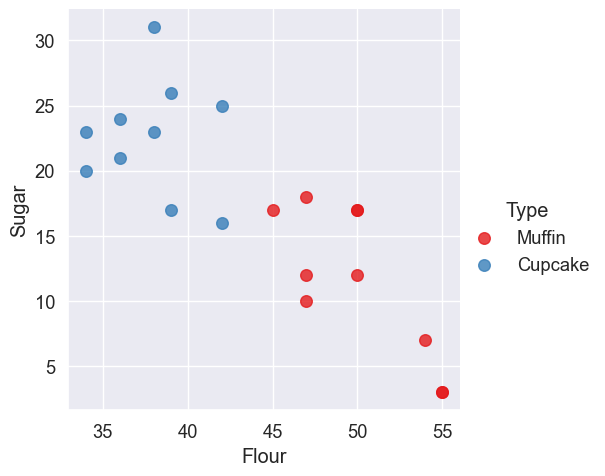

In [9]:
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type', palette='Set1', fit_reg=False,scatter_kws={'s':70});
plt.show()

In [10]:
type_label=np.where(recipes['Type']=='Muffin',0,1)
recipe_features=recipes.columns.values[1:].tolist()
recipe_features

['Flour', 'Milk', 'Sugar', 'Butter', 'Egg', 'Baking Powder', 'Vanilla', 'Salt']

In [11]:
ingredients=recipes[['Flour','Sugar']].values

In [12]:
model=svm.SVC(kernel='linear')
model.fit(ingredients,type_label)

SVC(kernel='linear')

In [13]:
w=model.coef_[0]
print(w)
a=-w[0]/w[1]
print(a)
xx=np.linspace(30,60)
print(xx)

[-6.66503014e-01 -7.77156117e-16]
-857617921181270.0
[30.         30.6122449  31.2244898  31.83673469 32.44897959 33.06122449
 33.67346939 34.28571429 34.89795918 35.51020408 36.12244898 36.73469388
 37.34693878 37.95918367 38.57142857 39.18367347 39.79591837 40.40816327
 41.02040816 41.63265306 42.24489796 42.85714286 43.46938776 44.08163265
 44.69387755 45.30612245 45.91836735 46.53061224 47.14285714 47.75510204
 48.36734694 48.97959184 49.59183673 50.20408163 50.81632653 51.42857143
 52.04081633 52.65306122 53.26530612 53.87755102 54.48979592 55.10204082
 55.71428571 56.32653061 56.93877551 57.55102041 58.16326531 58.7755102
 59.3877551  60.        ]


In [14]:
yy=a*xx-(model.intercept_[0])/w[1]

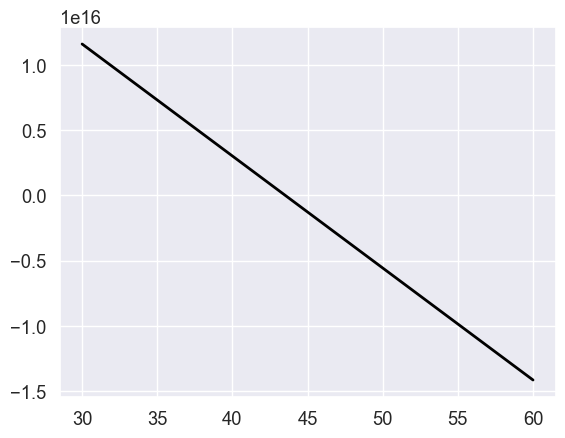

In [15]:
plt.plot(xx,yy,linewidth=2,color='black');
plt.show()

In [16]:
#plot the parallels to the separating hyperplane that pass through the support
b=model.support_vectors_[0]
print(b)
yy_down=a*xx+(b[1]-a*b[0])
b=model.support_vectors_[-1]
print(b)
yy_up=a*xx+(b[1]-a*b[0])

[45. 17.]
[42. 25.]


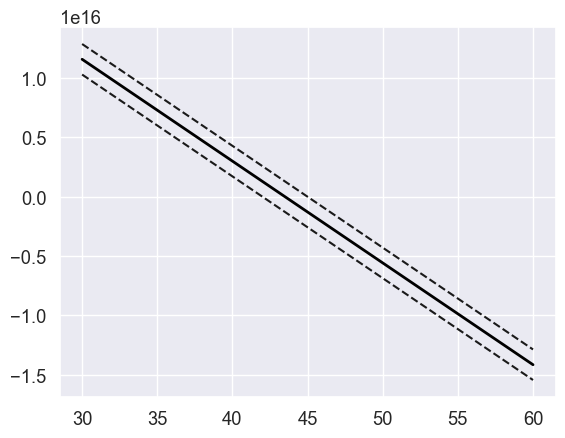

In [17]:
plt.plot(xx,yy,linewidth=2,color='black')
plt.plot(xx,yy_down,'k--')
plt.plot(xx,yy_up,'k--');
plt.show()

In [18]:
#create a function to predict muffin or cupcake
def muffin_or_cupcake(flour,sugar):
    if(model.predict([[flour,sugar]]))==0:
        print('This is a muffin recipe!')
    else:
        print('This is a cupcake recipe!')
        

In [19]:
#predict
muffin_or_cupcake(50,20)

This is a muffin recipe!


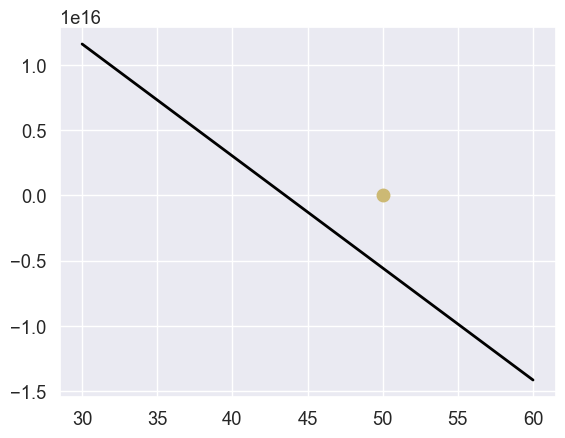

In [20]:
plt.plot(xx,yy,linewidth=2,color='black')
plt.plot(50,20,'yo',markersize='9');
plt.show()

In [21]:
muffin_or_cupcake(40,20)

This is a cupcake recipe!
